# 1. 데이터 다운로드

In [2]:
!tar -zxvf ./datasets_ko_en/korean-english-park.dev.tar.gz -C ./datasets_ko_en/
!tar -zxvf ./datasets_ko_en/korean-english-park.test.tar.gz -C ./datasets_ko_en/
!tar -zxvf ./datasets_ko_en/korean-english-park.train.tar.gz -C ./datasets_ko_en/

korean-english-park.dev.en
korean-english-park.dev.ko
korean-english-park.test.en
korean-english-park.test.ko
korean-english-park.train.en
korean-english-park.train.ko


# 2. 데이터 정제

In [3]:
import os
import re
import urllib.request
import zipfile
import sentencepiece as spm
import pandas as pd

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

from tqdm import tqdm
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.__version__)

2.7.1+cu118


In [4]:
def load_parallel_corpus(en_path, ko_path):
    with open(en_path, "r", encoding="utf-8") as f:
        en_lines = [line.strip() for line in f]

    with open(ko_path, "r", encoding="utf-8") as f:
        ko_lines = [line.strip() for line in f]

    assert len(en_lines) == len(ko_lines), "영어/한국어 파일의 줄 수가 다릅니다."

    return list(zip(en_lines, ko_lines))


In [6]:
train_pairs = load_parallel_corpus(
    "./datasets_ko_en/korean-english-park.train.en",
    "./datasets_ko_en/korean-english-park.train.ko"
)

dev_pairs = load_parallel_corpus(
    "./datasets_ko_en/korean-english-park.dev.en",
    "./datasets_ko_en/korean-english-park.dev.ko"
)

test_pairs = load_parallel_corpus(
    "./datasets_ko_en/korean-english-park.test.en",
    "./datasets_ko_en/korean-english-park.test.ko"
)


In [7]:
train_df = pd.DataFrame(train_pairs, columns=["en", "ko"])
train_df.head()


,en,ko
0,"Much of personal computing is about ""can you t...","개인용 컴퓨터 사용의 상당 부분은 ""이것보다 뛰어날 수 있느냐?"""
1,so a mention a few weeks ago about a rechargea...,모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하...
2,"Like all optical mice, But it also doesn't nee...",그러나 이것은 또한 책상도 필요로 하지 않는다.
3,uses gyroscopic sensors to control the cursor ...,"79.95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목, 팔, 그외에 어떤 부분..."
4,Intelligence officials have revealed a spate o...,정보 관리들은 동남 아시아에서의 선박들에 대한 많은 (테러) 계획들이 실패로 돌아갔...


## 2-1. 중복 제거

In [8]:
def remove_duplicates(pairs):
    cleaned_corpus = sorted(set(pairs))
    return cleaned_corpus

## 2-2. Missing Data 처리

데이터파일열어보면 번역: 어휘: 만써있고 번역이 안되어있는 글들이있음. 그래서 글자 길이 8 미만은 모두 쌍으로 제거함.

In [11]:
import re

def count_korean_chars(sentence):
    return len(re.findall(r"[가-힣]", sentence))
    
def remove_short_korean_pairs(pairs, min_korean_chars=9):
    filtered_pairs = []

    for en_sentence, ko_sentence in pairs:
        if count_korean_chars(ko_sentence) >= min_korean_chars:
            filtered_pairs.append((en_sentence, ko_sentence))

    return filtered_pairs

## 2-3. 정규식 함수

In [96]:
def preprocess_english(sentence):
    sentence = sentence.lower().strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r"[^a-zA-Z?.!,']+", " ", sentence)  # ' 추가
    sentence = re.sub(r"\s+", " ", sentence)
    return sentence.strip()


In [13]:
def preprocess_korean(sentence):
    sentence = sentence.strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r"[^가-힣ㄱ-ㅎㅏ-ㅣa-zA-Z0-9?.!,]+", " ", sentence)
    sentence = re.sub(r"\s+", " ", sentence)
    return sentence.strip()


In [20]:
!pip install python-mecab-ko

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 579.6/579.6 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 58.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [python-mecab-ko]dic]


## 2-4. 영어를 target으로 start, end 를 붙임

한글 토큰화를위해 Mecab 사용

In [97]:
from mecab import MeCab

mecab = MeCab()

def tokenize_pair(en_sentence, ko_sentence):
    en_sentence = preprocess_english(en_sentence)
    ko_sentence = preprocess_korean(ko_sentence)

    eng_tokens = ["<start>"] + en_sentence.split() + ["<end>"]
    kor_tokens = mecab.morphs(ko_sentence)

    return eng_tokens, kor_tokens


## 2-5. 최대길이 40짜리 corpus 생성

In [98]:

MAX_LEN = 40

def build_corpus(pairs, max_len=40):
    pairs = remove_short_korean_pairs(pairs)
    cleaned_corpus = remove_duplicates(pairs)

    eng_corpus = []
    kor_corpus = []

    for en_sentence, ko_sentence in cleaned_corpus:
        eng_tokens, kor_tokens = tokenize_pair(en_sentence, ko_sentence)

        if len(eng_tokens) <= max_len and len(kor_tokens) <= max_len:
            eng_corpus.append(eng_tokens)
            kor_corpus.append(kor_tokens)

    return eng_corpus, kor_corpus


In [99]:
train_eng_corpus, train_kor_corpus = build_corpus(train_pairs, MAX_LEN)
dev_eng_corpus, dev_kor_corpus = build_corpus(dev_pairs, MAX_LEN)
test_eng_corpus, test_kor_corpus = build_corpus(test_pairs, MAX_LEN)

print(len(train_eng_corpus), len(train_kor_corpus))
print(len(dev_eng_corpus), len(dev_kor_corpus))
print(len(test_eng_corpus), len(test_kor_corpus))


59701 59701
773 773
1473 1473


### 정제 데이터 확인

특히 원본데이터 한국어 28 31번 라인이 번역이 비어있어서 그걸본다.

In [25]:
for i in range(3):
    print("KOR:", train_kor_corpus[i])
    print("ENG:", train_eng_corpus[i])
    print()


KOR: ['키신저', '는', '마오쩌둥', '의', '제안', '을', '농담', '으로', '받아들이', '며', '한', '번', '연구', '를', '해봐야겠다', '고', '대답', '했', '다', '.']
ENG: ['<start>', 'it', 'is', 'such', 'a', 'novel', 'proposition', ',', 'kissinger', 'replied', 'in', 'his', 'discussion', 'with', 'mao', 'in', 'beijing', '.', '<end>']

KOR: ['그', '는', '당신', '이', '조니', '뎁', '아닌', '가요', '라는', '질문', '이', '결정', '적', '인', '증거', '일', '것', '이', '라고', '전했', '다', '.']
ENG: ['<start>', 'didn', 't', 'you', 'used', 'to', 'be', 'johnny', 'depp', '?', 'that', 'will', 'be', 'the', 'clincher', '.', '<end>']

KOR: ['사르코지', '의', '대변인', '은', '프랑스', '대통령', '이', '개막식', '불참', '에', '대해', '신중', '하', '게', '생각', '하', '고', '있', '다고', '전했', '다', '.']
ENG: ['<start>', 'a', 'spokesman', 'for', 'the', 'president', 'confirmed', 'that', 'sarkozy', 'was', 'referring', 'to', 'a', 'possible', 'snub', 'of', 'the', 'august', 'opening', 'ceremony', '.', '<end>']



## 3. 데이터 토큰화

In [26]:
from collections import Counter
import torch
from torch.nn.utils.rnn import pad_sequence

In [27]:
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
BOS_TOKEN = "<start>"
EOS_TOKEN = "<end>"

PAD_ID = 0
UNK_ID = 1
BOS_ID = 2
EOS_ID = 3


In [28]:
class Vocab:
    def __init__(self, tokenized_corpus, vocab_size):
        counter = Counter()

        for tokens in tokenized_corpus:
            counter.update(tokens)

        special_tokens = [PAD_TOKEN, UNK_TOKEN, BOS_TOKEN, EOS_TOKEN]

        self.idx_to_token = special_tokens.copy()
        self.token_to_idx = {
            token: idx for idx, token in enumerate(self.idx_to_token)
        }

        for token, _ in counter.most_common(vocab_size - len(special_tokens)):
            if token not in self.token_to_idx:
                self.token_to_idx[token] = len(self.idx_to_token)
                self.idx_to_token.append(token)

    def encode(self, tokens):
        return [
            self.token_to_idx.get(token, UNK_ID)
            for token in tokens
        ]

    def decode(self, ids):
        return [
            self.idx_to_token[idx]
            for idx in ids
            if idx not in [PAD_ID, BOS_ID, EOS_ID]
        ]

    def __len__(self):
        return len(self.idx_to_token)


In [94]:
print(len(enc_tokenizer))  # 10000인지
print("키신저" in enc_tokenizer.token_to_idx)  # True여야 함
print(enc_tokenizer.token_to_idx.get("키신저", "MISSING"))

10000
False
MISSING


In [95]:
from collections import Counter
all_kor_tokens = [t for sent in train_kor_corpus for t in sent]
print(f"고유 토큰 수: {len(set(all_kor_tokens))}")
print(f"전체 토큰 수: {len(all_kor_tokens)}")


고유 토큰 수: 44967
전체 토큰 수: 1523905


In [29]:
def tokenize(corpus, vocab_size):
    tokenizer = Vocab(corpus, vocab_size)

    tensor = [
        torch.tensor(tokenizer.encode(tokens), dtype=torch.long)
        for tokens in corpus
    ]

    tensor = pad_sequence(
        tensor,
        batch_first=True,
        padding_value=PAD_ID
    )

    return tensor, tokenizer


In [30]:
SRC_VOCAB_SIZE = 10000   # Korean
TGT_VOCAB_SIZE = 10000   # English

enc_tensor, enc_tokenizer = tokenize(train_kor_corpus, SRC_VOCAB_SIZE)
dec_tensor, dec_tokenizer = tokenize(train_eng_corpus, TGT_VOCAB_SIZE)

print(enc_tensor.shape)
print(dec_tensor.shape)
print(len(enc_tokenizer))
print(len(dec_tokenizer))


torch.Size([59462, 40])
torch.Size([59462, 40])
10000
9998


In [31]:
print(train_kor_corpus[0])
print(enc_tensor[0])

print(train_eng_corpus[0])
print(dec_tensor[0])


['키신저', '는', '마오쩌둥', '의', '제안', '을', '농담', '으로', '받아들이', '며', '한', '번', '연구', '를', '해봐야겠다', '고', '대답', '했', '다', '.']
tensor([   1,    7,    1,    9,  616,    8, 5121,   22, 2207,   48,   20,  124,
         251,   13,    1,   15, 1882,   12,    5,    4,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0])
['<start>', 'it', 'is', 'such', 'a', 'novel', 'proposition', ',', 'kissinger', 'replied', 'in', 'his', 'discussion', 'with', 'mao', 'in', 'beijing', '.', '<end>']
tensor([   2,   20,   17,  225,    9, 4486,    1,    6,    1, 5822,   10,   28,
        3438,   19,    1,   10,  347,    5,    3,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0])


In [33]:
from torch.utils.data import Dataset, DataLoader

class TranslationDataset(Dataset):
    def __init__(self, src_tensor, tgt_tensor):
        self.src_tensor = src_tensor
        self.tgt_tensor = tgt_tensor

    def __len__(self):
        return len(self.src_tensor)

    def __getitem__(self, idx):
        src = self.src_tensor[idx]

        tgt = self.tgt_tensor[idx]
        tgt_input = tgt[:-1]
        tgt_label = tgt[1:]

        return src, tgt_input, tgt_label


In [34]:
BATCH_SIZE = 64

dataset = TranslationDataset(enc_tensor, dec_tensor)
train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)


In [35]:
input_dim = len(enc_tokenizer)
output_dim = len(dec_tokenizer)

pad_id = PAD_ID
bos_id = BOS_ID
eos_id = EOS_ID


In [37]:
src, tgt_input, tgt_label = next(iter(train_loader))

print(src.shape)
print(tgt_input.shape)
print(tgt_label.shape)

print(input_dim, output_dim)
print(pad_id, bos_id, eos_id)


torch.Size([64, 40])
torch.Size([64, 39])
torch.Size([64, 39])
10000 9998
0 2 3


In [81]:
src, tgt_input, tgt_label = next(iter(train_loader))

src = src.to(device)
tgt_input = tgt_input.to(device)
tgt_label = tgt_label.to(device)

outputs, attentions = model(src, trg=tgt_input, bos_id=bos_id, eos_id=eos_id)

print(outputs.shape)
print(tgt_label.shape)


torch.Size([64, 39, 9998])
torch.Size([64, 39])


# 4. 모델 설계

In [38]:
import torch
import torch.nn as nn
import torch.nn.functional as F


In [39]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.W_enc = nn.Linear(hidden_dim, hidden_dim)
        self.W_dec = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, decoder_hidden, encoder_outputs, src_mask=None):
        # decoder_hidden: (batch, hidden_dim)
        # encoder_outputs: (batch, src_len, hidden_dim)

        decoder_hidden = decoder_hidden.unsqueeze(1)

        energy = torch.tanh(
            self.W_enc(encoder_outputs) + self.W_dec(decoder_hidden)
        )

        scores = self.v(energy).squeeze(-1)

        if src_mask is not None:
            scores = scores.masked_fill(src_mask == 0, -1e10)

        attention_weights = F.softmax(scores, dim=1)

        context = torch.bmm(
            attention_weights.unsqueeze(1),
            encoder_outputs
        ).squeeze(1)

        return context, attention_weights


In [40]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim, pad_id, dropout=0.3):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=pad_id)
        self.dropout = nn.Dropout(dropout)
        self.rnn = nn.GRU(
            emb_dim,
            hidden_dim,
            batch_first=True
        )

    def forward(self, src):
        # src: (batch, src_len)

        embedded = self.dropout(self.embedding(src))
        outputs, hidden = self.rnn(embedded)

        # outputs: (batch, src_len, hidden_dim)
        # hidden: (1, batch, hidden_dim)
        return outputs, hidden


In [42]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, pad_id, dropout=0.3):
        super().__init__()

        self.output_dim = output_dim
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=pad_id)
        self.dropout = nn.Dropout(dropout)
        self.attention = BahdanauAttention(hidden_dim)

        self.rnn = nn.GRU(
            emb_dim + hidden_dim,
            hidden_dim,
            batch_first=True
        )

        self.fc_out = nn.Linear(
            emb_dim + hidden_dim + hidden_dim,
            output_dim
        )

    def forward(self, input_token, hidden, encoder_outputs, src_mask=None):
        # input_token: (batch,)
        # hidden: (1, batch, hidden_dim)
        # encoder_outputs: (batch, src_len, hidden_dim)

        input_token = input_token.unsqueeze(1)

        embedded = self.dropout(self.embedding(input_token))
        # embedded: (batch, 1, emb_dim)

        context, attention_weights = self.attention(
            hidden[-1],
            encoder_outputs,
            src_mask
        )
        # context: (batch, hidden_dim)

        rnn_input = torch.cat(
            [embedded, context.unsqueeze(1)],
            dim=2
        )

        output, hidden = self.rnn(rnn_input, hidden)
        # output: (batch, 1, hidden_dim)

        output = output.squeeze(1)
        embedded = embedded.squeeze(1)

        prediction = self.fc_out(
            torch.cat([output, context, embedded], dim=1)
        )

        return prediction, hidden, attention_weights


In [79]:
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, pad_id, device):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.pad_id = pad_id
        self.device = device

    def make_src_mask(self, src):
        return (src != self.pad_id)

    def forward(self, src, trg=None, max_len=40, bos_id=2, eos_id=3):
        batch_size = src.size(0)

        src_mask = self.make_src_mask(src)

        encoder_outputs, hidden = self.encoder(src)

        outputs = []
        attentions = []

        if trg is not None:
            input_token = trg[:, 0]
            decode_len = trg.size(1)

            for t in range(decode_len):
                output, hidden, attention = self.decoder(
                    input_token,
                    hidden,
                    encoder_outputs,
                    src_mask
                )

                outputs.append(output.unsqueeze(1))
                attentions.append(attention.unsqueeze(1))

                if t + 1 < decode_len:
                    input_token = trg[:, t + 1]

        else:
            input_token = torch.full(
                (batch_size,),
                bos_id,
                dtype=torch.long,
                device=self.device
            )

            finished = torch.zeros(
                batch_size,
                dtype=torch.bool,
                device=self.device
            )

            for _ in range(max_len):
                output, hidden, attention = self.decoder(
                    input_token,
                    hidden,
                    encoder_outputs,
                    src_mask
                )

                outputs.append(output.unsqueeze(1))
                attentions.append(attention.unsqueeze(1))

                input_token = output.argmax(dim=1)

                finished |= (input_token == eos_id)
                if finished.all():
                    break

        outputs = torch.cat(outputs, dim=1)
        attentions = torch.cat(attentions, dim=1)

        return outputs, attentions


### 모델: model 생성

In [80]:
EMB_DIM = 256
HID_DIM = 512
DROPOUT = 0.3

encoder = Encoder(
    input_dim=input_dim,
    emb_dim=EMB_DIM,
    hidden_dim=HID_DIM,
    pad_id=pad_id,
    dropout=DROPOUT
).to(device)

decoder = Decoder(
    output_dim=output_dim,
    emb_dim=EMB_DIM,
    hidden_dim=HID_DIM,
    pad_id=pad_id,
    dropout=DROPOUT
).to(device)

model = Seq2SeqAttention(
    encoder=encoder,
    decoder=decoder,
    pad_id=pad_id,
    device=device
).to(device)

print(model)


Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(10000, 256, padding_idx=0)
    (dropout): Dropout(p=0.3, inplace=False)
    (rnn): GRU(256, 512, batch_first=True)
  )
  (decoder): Decoder(
    (embedding): Embedding(9998, 256, padding_idx=0)
    (dropout): Dropout(p=0.3, inplace=False)
    (attention): BahdanauAttention(
      (W_enc): Linear(in_features=512, out_features=512, bias=True)
      (W_dec): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (rnn): GRU(768, 512, batch_first=True)
    (fc_out): Linear(in_features=1280, out_features=9998, bias=True)
  )
)


### 모델: Shape Test

In [45]:
src, tgt_input, tgt_label = next(iter(train_loader))

src = src.to(device)
tgt_input = tgt_input.to(device)
tgt_label = tgt_label.to(device)

outputs, attentions = model(
    src,
    trg=tgt_input,
    bos_id=bos_id,
    eos_id=eos_id
)

print(outputs.shape)
print(tgt_label.shape)
print(attentions.shape)


torch.Size([64, 38, 9998])
torch.Size([64, 39])
torch.Size([64, 38, 40])


여기서 outputs 길이가 tgt_label보다 1 짧게 나올 수 있습니다.

그래서 학습 loss 계산할 때는 label도 맞춰서 잘라야 합니다.

In [47]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)

In [48]:
loss = criterion(
    outputs.reshape(-1, outputs.shape[-1]),
    tgt_label[:, 1:].reshape(-1)
)

In [49]:
print(loss.item())

9.27060317993164


# 5. 훈련하기

In [ ]:
EMB_DIM = 256
HID_DIM = 512
DROPOUT = 0.3
BATCH_SIZE = 64
LR = 1e-3


### 데이터가 나뉘어져있어서 검증데이터도 만들긴했었는데 일단 LMS 노드 설명에서 ❗ 주의: 난이도에 비해 데이터가 많지 않아 훈련 데이터와 검증 데이터를 따로 나누지는 않습니다. 라는내용이 있어서 가이드를 따라감.

### train_step

In [82]:
def train_step(model, data_loader, optimizer, criterion, epoch):
    model.train()
    epoch_loss = 0

    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)

    for src, tgt_input, tgt_label in progress_bar:
        src = src.to(device)
        tgt_input = tgt_input.to(device)
        tgt_label = tgt_label.to(device)

        optimizer.zero_grad()

        outputs, _ = model(
            src,
            trg=tgt_input,
            bos_id=bos_id,
            eos_id=eos_id
        )

        loss = criterion(
            outputs.contiguous().view(-1, outputs.shape[-1]),
            tgt_label.contiguous().view(-1)
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        epoch_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())

    return epoch_loss / len(data_loader)


### dropout과 early stopping이 적용된 훈련코드

In [53]:
%%time

EPOCHS = 10
patience = 3
min_delta = 0.001

best_train_loss = float("inf")
patience_count = 0
best_model_state = None

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)

    print(f"Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}")

    if train_loss < best_train_loss - min_delta:
        best_train_loss = train_loss
        patience_count = 0
        best_model_state = {
            key: value.detach().cpu().clone()
            for key, value in model.state_dict().items()
        }
    else:
        patience_count += 1
        print(f"EarlyStopping patience: {patience_count}/{patience}")

    if patience_count >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

if best_model_state is not None:
    model.load_state_dict({
        key: value.to(device)
        for key, value in best_model_state.items()
    })

print(f"Best Train Loss: {best_train_loss:.4f}")


Epoch 1: 100%|██████████| 930/930 [03:02<00:00,  5.08it/s, loss=5.4] 


Epoch 1/10, Train Loss: 5.8495


Epoch 2: 100%|██████████| 930/930 [03:02<00:00,  5.09it/s, loss=4.43]


Epoch 2/10, Train Loss: 5.0241


Epoch 3: 100%|██████████| 930/930 [03:02<00:00,  5.09it/s, loss=4.13]


...

Epoch 8/10, Train Loss: 3.4763


Epoch 9: 100%|██████████| 930/930 [03:03<00:00,  5.07it/s, loss=3.5] 


Epoch 9/10, Train Loss: 3.3805


Epoch 10: 100%|██████████| 930/930 [03:02<00:00,  5.08it/s, loss=3.52]


Epoch 10/10, Train Loss: 3.3031
Best Train Loss: 3.3031
CPU times: user 30min 1s, sys: 38.3 s, total: 30min 39s
Wall time: 30min 30s


### 5-1 번역용 함수

In [54]:
def ids_to_sentence(ids, tokenizer):
    tokens = tokenizer.decode(ids)

    tokens = [
        token for token in tokens
        if token not in [PAD_TOKEN, BOS_TOKEN, EOS_TOKEN]
    ]

    return " ".join(tokens)


In [55]:
def translate(sentence, model, enc_tokenizer, dec_tokenizer, max_len=40):
    model.eval()

    sentence = preprocess_korean(sentence)
    src_tokens = mecab.morphs(sentence)

    src_ids = enc_tokenizer.encode(src_tokens)
    src_tensor = torch.tensor(src_ids, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs, attentions = model(
            src_tensor,
            trg=None,
            max_len=max_len,
            bos_id=bos_id,
            eos_id=eos_id
        )

    pred_ids = outputs.argmax(dim=-1).squeeze(0).tolist()

    result_tokens = []
    for idx in pred_ids:
        if idx == eos_id:
            break
        if idx not in [pad_id, bos_id]:
            result_tokens.append(dec_tokenizer.idx_to_token[idx])

    return " ".join(result_tokens), attentions.squeeze(0).cpu()


In [58]:
sample_sentences = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다",
    "일곱 명의 사망자가 발생했다.",
]


In [67]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import logging

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

fontpath = "./fonts/NanumBarunGothic.ttf"
fontprop = fm.FontProperties(fname=fontpath, size=12)
plt.rcParams["font.family"] = fontprop.get_name()

print(f"설정된 폰트: {fontprop.get_name()}")

설정된 폰트: NanumBarunGothic


In [61]:
for sentence in sample_sentences:
    translation, attention = translate(
        sentence,
        model,
        enc_tokenizer,
        dec_tokenizer,
        max_len=40
    )

    print(f"KOR: {sentence}")
    print(f"ENG: {translation}")
    print()


KOR: 오바마는 대통령이다.
ENG: obama inauguration resignation president obama tuesday president obama the senator illinois president obama president obama president obama president obama president obama president obama president obama president obama president obama president obama

KOR: 시민들은 도시 속에 산다.
ENG: spectators citizens to citizen in city cities the city the of city <unk> the city <unk> the of city <unk> the of city tourists locals the of town locals the . . citizens citizens

KOR: 커피는 필요 없다
ENG: coffee cannot coffee <unk> coffee , never any . need required possess coffee . cannot coffee <unk>

KOR: 일곱 명의 사망자가 발생했다.
ENG: death rose among least people killed least and others including in , civil . . deaths people



In [72]:
def show_attention(sentence, translation, attention):
    src_sentence = preprocess_korean(sentence)
    src_tokens = mecab.morphs(src_sentence)

    pred_tokens = translation.split()

    attention = attention[:len(pred_tokens), :len(src_tokens)]

    fig, ax = plt.subplots(
        figsize=(
            max(8, len(src_tokens) * 0.6),
            max(5, len(pred_tokens) * 0.4)
        )
    )

    cax = ax.matshow(attention.detach().cpu().numpy(), cmap="bone")
    fig.colorbar(cax)

    ax.set_xticks(range(len(src_tokens)))
    ax.set_yticks(range(len(pred_tokens)))

    ax.set_xticklabels(src_tokens, rotation=45, ha="left")
    ax.set_yticklabels(pred_tokens)

    ax.set_xlabel("Korean Input")
    ax.set_ylabel("English Output")

    plt.tight_layout()
    plt.show()


KOR: 일곱 명의 사망자가 발생했다.
ENG: death rose among least people killed least and others including in , civil . . deaths people


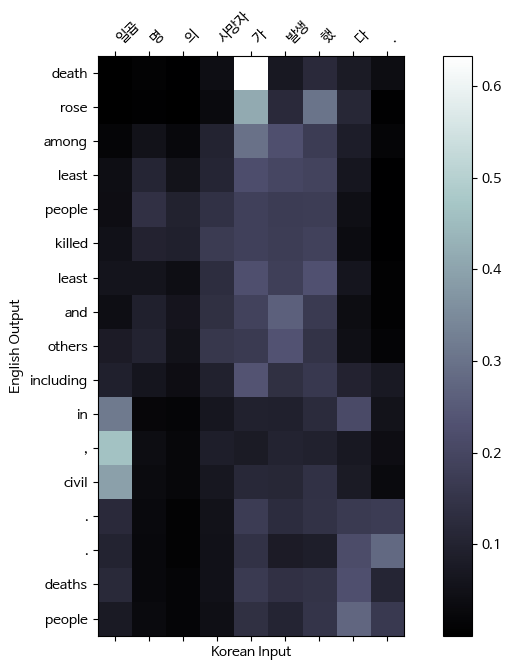

In [73]:
sentence = "일곱 명의 사망자가 발생했다."

translation, attention = translate(
    sentence,
    model,
    enc_tokenizer,
    dec_tokenizer,
    max_len=40
)

print("KOR:", sentence)
print("ENG:", translation)

show_attention(sentence, translation, attention)


학습 방법 변경

In [88]:
EMB_DIM = 256
HID_DIM = 512
DROPOUT = 0.3
LR = 1e-3


In [89]:
def init_training():
    encoder = Encoder(input_dim, EMB_DIM, HID_DIM, pad_id, DROPOUT).to(device)
    decoder = Decoder(output_dim, EMB_DIM, HID_DIM, pad_id, DROPOUT).to(device)
    model = Seq2SeqAttention(encoder, decoder, pad_id, device).to(device)

    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss(ignore_index=pad_id)
    return model, optimizer, criterion

model, optimizer, criterion = init_training()


In [92]:
%%time

EPOCHS = 10
patience = 3
min_delta = 0.001

best_train_loss = float("inf")
patience_count = 0
best_model_state = None

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)

    print(f"Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}")

    if train_loss < best_train_loss - min_delta:
        best_train_loss = train_loss
        patience_count = 0
        best_model_state = {
            key: value.detach().cpu().clone()
            for key, value in model.state_dict().items()
        }
    else:
        patience_count += 1
        print(f"EarlyStopping patience: {patience_count}/{patience}")

    if patience_count >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

if best_model_state is not None:
    model.load_state_dict({
        key: value.to(device)
        for key, value in best_model_state.items()
    })

print(f"Best Train Loss: {best_train_loss:.4f}")


Epoch 1: 100%|██████████| 930/930 [03:07<00:00,  4.96it/s, loss=4.59]


Epoch 1/10, Train Loss: 4.7704


Epoch 2: 100%|██████████| 930/930 [03:07<00:00,  4.95it/s, loss=3.53]


Epoch 2/10, Train Loss: 3.9793


Epoch 3: 100%|██████████| 930/930 [03:07<00:00,  4.95it/s, loss=3.85]


...

Epoch 8/10, Train Loss: 2.5820


Epoch 9: 100%|██████████| 930/930 [03:08<00:00,  4.94it/s, loss=2.32]


Epoch 9/10, Train Loss: 2.4936


Epoch 10: 100%|██████████| 930/930 [03:08<00:00,  4.94it/s, loss=2.76]


Epoch 10/10, Train Loss: 2.4227
Best Train Loss: 2.4227
CPU times: user 30min 46s, sys: 43.4 s, total: 31min 29s
Wall time: 31min 20s


In [93]:
for sentence in sample_sentences:
    translation, attention = translate(
        sentence,
        model,
        enc_tokenizer,
        dec_tokenizer,
        max_len=40
    )

    print(f"KOR: {sentence}")
    print(f"ENG: {translation}")
    print()


KOR: 오바마는 대통령이다.
ENG: obama is illinois to illinois obama s goal , obama said , and obama is lucky , obama s aides figure . obama is illinois to illinois obama , who is obama s president , obama said .

KOR: 시민들은 도시 속에 산다.
ENG: citizens used to celebrate the city s cities in cities .

KOR: 커피는 필요 없다
ENG: coffee , though is needed to find out , is no need to find out of coffee , especially t need to find out , but we don t need to find out there .

KOR: 일곱 명의 사망자가 발생했다.
ENG: at least people were killed , including others , and others were killed , although others were killed , others were wounded .

